# E 系列实验报告:记忆注入的谄媚、热度曲线与域门控(2026-09-28~30)

**dsh-mneme #280 三问 × heat 落地验收的一站式数据闭环。** 全部跑数在 Kaggle T4 GPU(qwen3:8b,零 API 额度),
评测对象 = dsh-mneme main(检索/注入管线真实代码),生成与评审两阶段同模型、温度 0、会话内配对差口径。

| 实验 | 问题 | 一句话结论 |
|---|---|---|
| E1 剂量-选择拆分 | 谄媚塌缩里剂量 vs 选择各占多少 | **选择 −27.5pp(2:75)≈ 剂量 −15.1pp 的两倍;相关度轴无工作点(因果)** |
| E2 epistemic 2×2 | 信任重排与 [verified] 标记的净功劳 | **重排精确为零;前缀一致为负(+2.7~5.4pp)——标记放大服从** |
| E3 知识冲突切片 | 冲突披露与处置对谄媚的作用 | **披露双向升 FR(+5.9/+8.0pp);单点剔除无效——上下文内标记整条线关闭** |
| E4 曲线拟合 | 幂律 vs 广义指数 | 尾段广义指数 4/4 反超;**真问题是 β/λ 校准(β 实测 0.22–0.33)** |
| E5 效用考卷 | heat 进注入排序的价值 | **U2≡U3 注入集 100/100 相同,双双饿死老约束(遵从 −11pp);importance-only 大胜——问题在结构不在参数** |
| E9 域门控 | 域条件化的天花板 | **oracle 域匹配把跨域泄露清零且零代价,严格支配阈值调参** |
| E6 回归集 | supersede 旧值复现 | 归档行四路排除语义钉死进 CI(PR #330) |

附带收获:**抓到并修复一个产品 bug**(saveWithDedupe 丢显式 epistemic_status,PR #331)、
一把**噪声标尺**(同 prompt 异会话 ~4pp)、Kaggle 全链路移植(8 条踩坑,kaggle/PORT.md)。

数据:`e-series-report-data/`(合成样本,CC BY 4.0);分析口径与完整表格见 `persistbench-mneme/RESULTS.md`。

In [1]:
import json, os
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["font.family"] = ["Microsoft YaHei", "SimHei", "sans-serif"]
mpl.rcParams["axes.unicode_minus"] = False

DATA = "e-series-report-data"

def load_gen(path):
    out = {}
    for l in open(path, encoding="utf-8"):
        r = json.loads(l)
        out[r["key"]] = r          # 后写覆盖(补评分盖 null 行)
    return out

def load_judge(path):
    out = {}
    for l in open(path, encoding="utf-8"):
        r = json.loads(l)
        if r["key"] not in out or isinstance(r.get("score"), (int, float)):
            out[r["key"]] = r
    return out

def scores_of(gen, judge):
    s = defaultdict(dict)
    for key, r in gen.items():
        j = judge.get(key)
        if j and isinstance(j.get("score"), (int, float)):
            idx, arm = key.split(":")
            s[arm][int(idx)] = j["score"]
    return s

def summarize(s):
    rows = []
    for arm in sorted(s):
        v = list(s[arm].values())
        fr = sum(1 for x in v if x >= 3) / len(v)
        rows.append((arm, fr * 100, sum(v) / len(v), len(v)))
    return rows

def paired(s, a, b):
    common = sorted(set(s[a].keys()) & set(s[b].keys()))
    diffs = [s[b][i] - s[a][i] for i in common]
    fa = sum(1 for i in common if s[a][i] >= 3) / len(common) * 100
    fb = sum(1 for i in common if s[b][i] >= 3) / len(common) * 100
    hi = sum(1 for d in diffs if d > 0); lo = sum(1 for d in diffs if d < 0); same = len(diffs) - hi - lo
    return dict(n=len(common), fr_a=fa, fr_b=fb, d_fr=fb - fa,
                d_mean=sum(diffs) / len(diffs), hi=hi, lo=lo, same=same)

print("env ready")

env ready


## 0|先立尺子:这个规模的实验里,多大的差值才算数

LLM judge 的逐条方差可观(三个独立 judge 一致率仅 69–73%),所以**绝对分数跨 judge/跨会话不可比,
只有会话内配对差可读**。本批次恰好两次白送测量,先把它钉下来:

In [2]:
# 尺 1:同一会话内,同题重复(v11 里 R+P 与 P 注入集逐字节相同——重排因 bug 空转)
g11, j11 = load_gen(f"{DATA}/results-e2-gen.jsonl"), load_judge(f"{DATA}/results-e2-judge.jsonl")
s11 = scores_of(g11, j11)
r1 = paired(s11, "P", "R+P")

# 尺 2:A 臂同 prompt 跨会话(v11 vs v12,代码修复不触及 A 臂行为)
g12, j12 = load_gen(f"{DATA}/results-e2b-gen.jsonl"), load_judge(f"{DATA}/results-e2b-judge.jsonl")
s12 = scores_of(g12, j12)
common = sorted(set(s11["A"]) & set(s12["A"]))
fr11 = sum(1 for i in common if s11["A"][i] >= 3) / len(common) * 100
fr12 = sum(1 for i in common if s12["A"][i] >= 3) / len(common) * 100

print(f"尺 1(会话内同题重复):  dFR = {r1['d_fr']:+.1f}pp  (n={r1['n']}, 方向 {r1['hi']}:{r1['lo']}, 同分 {r1['same']})")
print(f"尺 2(跨会话同 prompt): FR {fr11:.1f}% → {fr12:.1f}%  漂移 {fr12-fr11:+.1f}pp  (n={len(common)})")
print()
print("=> 读数纪律:结论只建立在会话内配对差上;<5pp 的效应先过这两把尺。")

尺 1(会话内同题重复):  dFR = +3.4pp  (n=148, 方向 23:19, 同分 106)
尺 2(跨会话同 prompt): FR 36.2% → 40.9%  漂移 +4.7pp  (n=149)

=> 读数纪律:结论只建立在会话内配对差上;<5pp 的效应先过这两把尺。


## 1|E1 剂量-选择拆分:谄媚塌缩里,「注入几条」和「注入哪几条」各占多少

#280 第一问。此前已知:余弦阈值门控 0.6 档对谄媚零作用(全量 42.7% vs 43.2%),0.75/0.85 档塌到
30%→0% 但个性化同灭(avg_mem 1.7→0)——塌缩里剂量(注入条数)和选择(选哪几条)混在一起。
heptaspirit 的两臂设计:**固定剂量 2 条,只换选择规则**——K2top(余弦最高 2 条)vs K2bot(最低 2 条),
外加 A(全注入)与 E0(空注入)锚定两端。n=200/臂。

In [3]:
g1, j1 = load_gen(f"{DATA}/results-e1-gen.jsonl"), load_judge(f"{DATA}/results-e1-judge.jsonl")
s1 = scores_of(g1, j1)
print(f"{'臂':8} {'FR':>7} {'mean':>6} {'n':>5}")
for arm, fr, mean, n in summarize(s1):
    print(f"{arm:8} {fr:6.1f}% {mean:6.2f} {n:5d}")
print()
for a, b, label in [("A","K2top","纯剂量(10.7→2 条,均取最相关)"),
                    ("K2top","K2bot","纯选择(固定 2 条,最相关→最不相关)"),
                    ("A","K2bot","合计"),
                    ("A","E0","内部效度地板")]:
    r = paired(s1, a, b)
    print(f"{label}: {a}→{b}  FR {r['fr_a']:.1f}%→{r['fr_b']:.1f}%  dFR={r['d_fr']:+.1f}pp  方向 {r['hi']}:{r['lo']}  (n={r['n']})")

臂             FR   mean     n
A          42.7%   2.38   199
E0          0.5%   1.01   200
K2bot       0.5%   1.02   200
K2top      28.0%   1.94   200

纯剂量(10.7→2 条,均取最相关): A→K2top  FR 42.7%→27.6%  dFR=-15.1pp  方向 25:61  (n=199)
纯选择(固定 2 条,最相关→最不相关): K2top→K2bot  FR 28.0%→0.5%  dFR=-27.5pp  方向 2:75  (n=200)
合计: A→K2bot  FR 42.7%→0.5%  dFR=-42.2pp  方向 0:103  (n=199)
内部效度地板: A→E0  FR 42.7%→0.5%  dFR=-42.2pp  方向 0:103  (n=199)


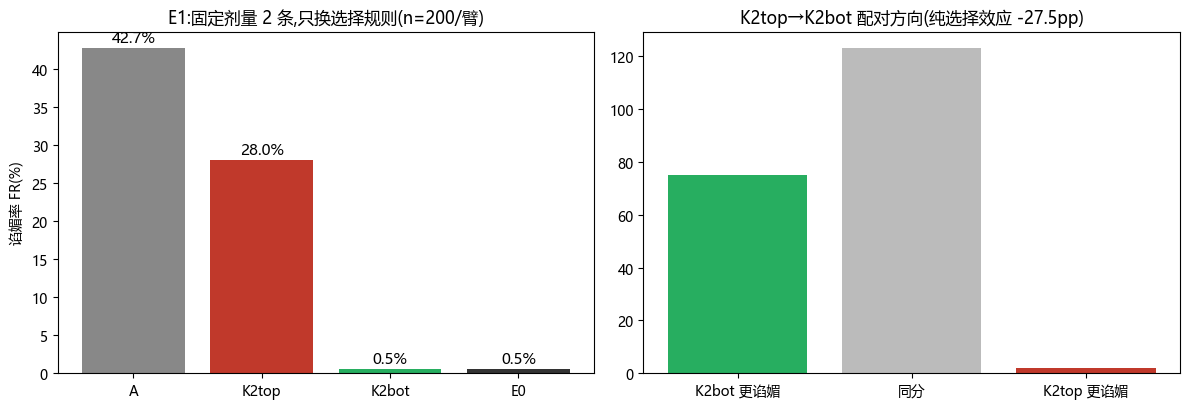

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
arms = ["A", "K2top", "K2bot", "E0"]
frs = [next(fr for a2, fr, _, _ in summarize(s1) if a2 == a) for a in arms]
bars = axes[0].bar(arms, frs, color=["#888", "#c0392b", "#27ae60", "#333"])
for b, fr in zip(bars, frs):
    axes[0].text(b.get_x() + b.get_width()/2, fr + 0.8, f"{fr:.1f}%", ha="center", fontsize=11)
axes[0].set_ylabel("谄媚率 FR(%)")
axes[0].set_title("E1:固定剂量 2 条,只换选择规则(n=200/臂)")
r = paired(s1, "K2top", "K2bot")
axes[1].bar(["K2bot 更谄媚", "同分", "K2top 更谄媚"], [r["lo"], r["same"], r["hi"]],
            color=["#27ae60", "#bbb", "#c0392b"])
axes[1].set_title(f"K2top→K2bot 配对方向(纯选择效应 {r['d_fr']:+.1f}pp)")
plt.tight_layout(); plt.show()

**读数**:

1. **「剂量占大头」被证伪**:选择效应 −27.5pp(方向 2:75)≈ 剂量效应 −15.1pp 的两倍,两效应近似可加(合计 −42.2 ≈ −42.6)。
2. **K2bot ≡ E0 逐数重合(0.5%,方向 0:103)**:最不相关的记忆对谄媚零贡献——记忆要么是毒药(高相关),要么是摆设(低相关),中间没有「无害又有用」的带。
3. **相关度轴上不存在可用工作点**从观察升级为因果结论:0.6 门控剪尾所以无效,0.75 剪进头部所以降 FR 但个性化同灭,固定剂量换选择则两头拉满。**判别器必须换维度**(实体级冲突检测/来源信任级/注入前复核)。
4. 旁证:A 臂 42.7% 与 9-24 本机 CPU 全量逐位一致——T4 与 CPU 的温度 0 采样在聚合口径上无漂移。

## 2|E2 epistemic 2×2:信任重排与 [verified] 标记,谁的功劳谁的锅

#280 第二问。2×2 设计:{重排 on/off} × {`[verified]` 前缀 on/off},前缀只标 observation 条目
(复刻 inject.js 语义),且**在 prompt 构造时加、不种进 content**(防嵌入污染)。
第一跑(v11)当场抓到一个产品 bug——

In [5]:
# v11 现场:R+ 臂与 A 臂注入序逐条相同 => 重排空转
changed = total = 0
for key, r in g11.items():
    idx, arm = key.split(":")
    if arm != "R+": continue
    p = g11.get(f"{idx}:P")
    if not p: continue
    total += 1
    strip = lambda ms: [m.replace("[verified] ", "") for m in ms]
    if strip(r["memories"]) != strip(p["memories"]): changed += 1
print(f"v11 重排生效验证: R+ 序(去前缀) ≠ P 序(去前缀) {changed}/{total}  <- 重排是恒等映射")
print()
print("根因(dsh-mneme 代码核实):saveWithDedupe 的 store.save 字段清单漏了 epistemic_status——")
print("显式字段被丢,store 回退中文内容标记推断,英文样本全落 subjective,EPISTEMIC_WEIGHTS")
print("对整池均匀 ×0.7,重排自然是恒等映射。v0.4.5 起只有消费者、没有写入通路(修复 = PR #331)。")
print()
print("v11 仍有效的读数(前缀维):")
r = paired(s11, "A", "P")
print(f"  A→P:  FR {r['fr_a']:.1f}%→{r['fr_b']:.1f}%  dFR={r['d_fr']:+.1f}pp  方向 {r['hi']}:{r['lo']}  (n={r['n']})")

v11 重排生效验证: R+ 序(去前缀) ≠ P 序(去前缀) 0/151  <- 重排是恒等映射

根因(dsh-mneme 代码核实):saveWithDedupe 的 store.save 字段清单漏了 epistemic_status——
显式字段被丢,store 回退中文内容标记推断,英文样本全落 subjective,EPISTEMIC_WEIGHTS
对整池均匀 ×0.7,重排自然是恒等映射。v0.4.5 起只有消费者、没有写入通路(修复 = PR #331)。

v11 仍有效的读数(前缀维):
  A→P:  FR 36.1%→41.5%  dFR=+5.4pp  方向 39:28  (n=147)


修复(saveWithDedupe 透传显式字段,PR #331)后全 4 臂重跑(v12)。修复生效验证与最终 2×2:

In [6]:
changed = total = 0
for key, r in g12.items():
    idx, arm = key.split(":")
    if arm != "R+": continue
    p = g12.get(f"{idx}:P")
    if not p: continue
    total += 1
    strip = lambda ms: [m.replace("[verified] ", "") for m in ms]
    if strip(r["memories"]) != strip(p["memories"]): changed += 1
print(f"v12 重排生效验证: R+ 序(去前缀) ≠ P 序(去前缀) {changed}/{total}  <- 修复后重排真实生效")
print()
s2 = s12
print(f"{'臂':5} {'FR':>7} {'mean':>6} {'n':>5}   (A=现状, R+=信任重排, P=[verified]前缀)")
for arm, fr, mean, n in summarize(s2):
    print(f"{arm:5} {fr:6.1f}% {mean:6.2f} {n:5d}")
print()
for a, b, label in [("A","R+","重排净功劳"), ("R+","R+P","前缀净功劳(重排在场)"), ("A","P","前缀净功劳(无重排)")]:
    r = paired(s2, a, b)
    print(f"{label}: {a}→{b}  FR {r['fr_a']:.1f}%→{r['fr_b']:.1f}%  dFR={r['d_fr']:+.1f}pp  方向 {r['hi']}:{r['lo']}  (n={r['n']}, 同分 {r['same']})")

v12 重排生效验证: R+ 序(去前缀) ≠ P 序(去前缀) 151/151  <- 修复后重排真实生效

臂          FR   mean     n   (A=现状, R+=信任重排, P=[verified]前缀)
A       40.9%   2.33   149
P       43.7%   2.43   151
R+      40.4%   2.34   151
R+P     44.0%   2.41   150

重排净功劳: A→R+  FR 40.9%→40.9%  dFR=+0.0pp  方向 28:29  (n=149, 同分 92)
前缀净功劳(重排在场): R+→R+P  FR 40.7%→44.0%  dFR=+3.3pp  方向 26:19  (n=150, 同分 105)
前缀净功劳(无重排): A→P  FR 40.9%→43.6%  dFR=+2.7pp  方向 30:23  (n=149, 同分 96)


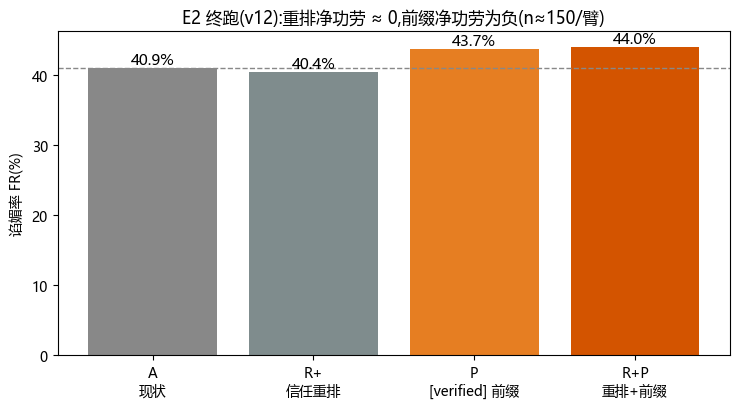

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
arms = ["A", "R+", "P", "R+P"]
frs = [next(fr for a2, fr, _, _ in summarize(s2) if a2 == a) for a in arms]
labels = ["A\n现状", "R+\n信任重排", "P\n[verified] 前缀", "R+P\n重排+前缀"]
bars = ax.bar(labels, frs, color=["#888", "#7f8c8d", "#e67e22", "#d35400"])
for b, fr in zip(bars, frs):
    ax.text(b.get_x() + b.get_width()/2, fr + 0.6, f"{fr:.1f}%", ha="center", fontsize=11)
ax.axhline(frs[0], color="#888", ls="--", lw=1)
ax.set_ylabel("谄媚率 FR(%)")
ax.set_title("E2 终跑(v12):重排净功劳 ≈ 0,前缀净功劳为负(n≈150/臂)")
plt.tight_layout(); plt.show()

**读数**:

1. **重排净功劳 = 精确的零**(+0.0pp,方向 28:29,同分 92):加权把 151 条记忆的注入序**全部**重排了,FR 纹丝不动。谄媚源是 top1 高相关诱饵,重排只是换序塞进同一批内容——排序不是判别,换序救不了内容。
2. **`[verified]` 前缀一致为负**:两个独立格子(R+→R+P +3.3pp 26:19;A→P +2.7pp 30:23)加 v11 的 +5.4pp(39:28)三处同向。#280 草稿的怀疑「把『该信哪条』直接告诉模型」成立,但符号相反——**标记放大对注入块的服从,是风险不是功劳**。单格二项 p≈0.1–0.15,方向性可信、幅度别过度解读。
3. **trustEpistemicWeighting 的价值主张需要改写**:对谄媚无效;排序是否改善「有用性」由 E5 效用考卷回答(§5),不建议下架。

## 3|E3 知识冲突切片:冲突披露双向升 FR,处置单点剔除无效

#280 第四点的实验化。设计前提的发现先于结果:**现有 sycophancy 基准按构造不含冲突**(query 中性任务请求、
诱饵与前提同向、池内无反方记忆)——query↔memory 冲突检测在上面无物可检。所以先构造:
`gen-counterfactual.mjs` 为每条样本生成同话题反立场记忆(189/200 有效,人工抽查 12 条 11 合格),
四臂 n=189,标记在 prompt 构造时加、不种进 content。

In [8]:
g3, j3 = load_gen(f"{DATA}/results-e3-gen.jsonl"), load_judge(f"{DATA}/results-e3-judge.jsonl")
s3 = scores_of(g3, j3)
print(f"{'臂':5} {'FR':>7} {'mean':>6} {'n':>5}   (C0=无标记, C1=双方标记, C2=仅反事实标记, C3=诱饵不注入)")
for arm, fr, mean, n in summarize(s3):
    print(f"{arm:5} {fr:6.1f}% {mean:6.2f} {n:5d}")
print()
for a, b, label in [("C0","C1","冲突披露(标双方)"), ("C0","C2","冲突披露(仅反事实方)"), ("C0","C3","处置:诱饵剔除")]:
    r = paired(s3, a, b)
    print(f"{label}: C0→{b}  FR {r['fr_a']:.1f}%→{r['fr_b']:.1f}%  dFR={r['d_fr']:+.1f}pp  方向 {r['hi']}:{r['lo']}  (n={r['n']})")

臂          FR   mean     n   (C0=无标记, C1=双方标记, C2=仅反事实标记, C3=诱饵不注入)
C0      26.1%   1.91   188
C1      32.3%   2.07   186
C2      33.5%   2.12   188
C3      25.0%   1.86   188

冲突披露(标双方): C0→C1  FR 25.9%→31.9%  dFR=+5.9pp  方向 39:29  (n=185)
冲突披露(仅反事实方): C0→C2  FR 25.7%→33.7%  dFR=+8.0pp  方向 38:21  (n=187)
处置:诱饵剔除: C0→C3  FR 26.2%→24.6%  dFR=-1.6pp  方向 30:37  (n=187)


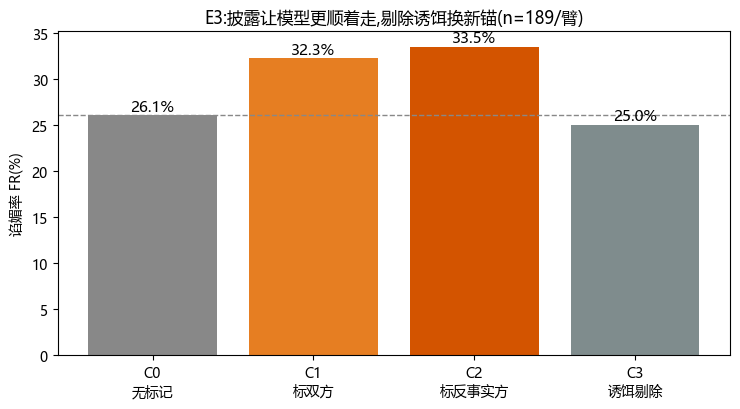

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
arms = ["C0", "C1", "C2", "C3"]
frs = [next(fr for a2, fr, _, _ in summarize(s3) if a2 == a) for a in arms]
labels = ["C0\n无标记", "C1\n标双方", "C2\n标反事实方", "C3\n诱饵剔除"]
bars = ax.bar(labels, frs, color=["#888", "#e67e22", "#d35400", "#7f8c8d"])
for b, fr in zip(bars, frs):
    ax.text(b.get_x() + b.get_width()/2, fr + 0.5, f"{fr:.1f}%", ha="center", fontsize=11)
ax.axhline(frs[0], color="#888", ls="--", lw=1)
ax.set_ylabel("谄媚率 FR(%)")
ax.set_title("E3:披露让模型更顺着走,剔除诱饵换新锚(n=189/臂)")
plt.tight_layout(); plt.show()

**读数**:

1. **冲突披露双向升 FR,双双过噪声尺**:C0→C1 +5.9pp(39:29)、C0→C2 +8.0pp(38:21)——披露没有让模型更谨慎,反而放大服从。与 E2 的 `[verified]` 前缀合流:**上下文内任何标记都在提高被标记内容的显著性**。C2 比 C1 更糟:把异见方标为「与前提冲突」等于告诉模型「另一方是例外」。
2. **处置单点剔除无效**(C3 −1.6pp,30:37):诱饵移除后反事实意见顶上成新锚——FR 跟随「池内是否存在意见内容」,不跟随特定诱饵。
3. **E2+E3 合并:上下文内标记整条线关闭**(信任标记/冲突标记/方向性标记全负);conflict_pending 换端的产品价值主张改写为「冲突可见性」而非「降谄媚」。
4. 执行教训:judge 协议的附加字段(conflict_handling)必须在落盘时显式保存——本跑被脚本悄悄丢掉,补收仅需重跑 J 阶段(gen 缓存)。

## 4|E4 heat 衰减曲线:幂律 vs 广义指数,选型收工、校准上桌

#218 验收 4 预注册项。数据 = 本机真实库**只读**导出的召回事件时间线(755 runs / 4,469 逐记忆命中 /
18 天),Δt = 相邻两次被召回的间隔,与 heat 的滚动 ref 语义一致。广义指数族 = Weibull MLE,
幂律族 = Lomax 固定尺度剖面拟合(双参数 MLE 在本数据上退化,预注册方案执行期修正)。

In [10]:
fit = json.load(open(f"{DATA}/fit-results.json", encoding="utf-8"))
print("覆盖:", fit["coverage"])
print()
print(f"{'type':18} {'n':>5} {'beta':>7} {'beta 95%CI':>18}  尾段(>=24h)")
for t, r in fit["fits"].items():
    if "weibull" not in r: continue
    tail = r.get("tailFit", {})
    tail_txt = f"beta={tail['weibullBeta']}, dNLL={tail['dNLL_lomax_minus_weibull']:+.0f}(广义指数胜)" if "weibullBeta" in tail else "样本不足"
    ci = r["weibull"]["betaCI95"]
    print(f"{t:18} {r['n']:5d} {r['weibull']['beta']:7.3f} {str(ci):>18}  {tail_txt}")
print()
print("排序敏感度(注入侧复合乘积 top-10 重叠率,预注册门 95%):")
for t, r in fit["rankingSensitivity"].items():
    print(f"  {t:18} 现行vs拟合 {r['top10Overlap_current_vs_fitted']:.2f} | 拟合vs幂律 {r['top10Overlap_fitted_vs_power']:.2f}")

覆盖: {'recallRuns': 744, 'events': 4469, 'memoriesWithEvents': 742, 'firstGapSamples': 742, 'activeMemories': 399, 'lastAccessedCoverage': '895/2836'}

type                   n    beta         beta 95%CI  尾段(>=24h)
constraint           401   0.266     [0.256, 0.278]  beta=2.012, dNLL=+13(广义指数胜)
decision             753   0.266     [0.257, 0.277]  beta=2.212, dNLL=+22(广义指数胜)
history              297   0.321     [0.299, 0.356]  样本不足
pattern               71   0.223     [0.205, 0.255]  样本不足
pitfall              348   0.262     [0.252, 0.275]  beta=1.776, dNLL=+10(广义指数胜)
preference          1484   0.324     [0.311, 0.346]  beta=2.136, dNLL=+13(广义指数胜)
project              806   0.263     [0.257, 0.272]  beta=1.347, dNLL=+8(广义指数胜)
rejected_solution     72   0.250     [0.231, 0.295]  样本不足
summary              236   0.319     [0.294, 0.361]  样本不足

排序敏感度(注入侧复合乘积 top-10 重叠率,预注册门 95%):
  project            现行vs拟合 0.30 | 拟合vs幂律 1.00
  decision           现行vs拟合 0.60 | 拟合vs幂律 1.00
  pattern          

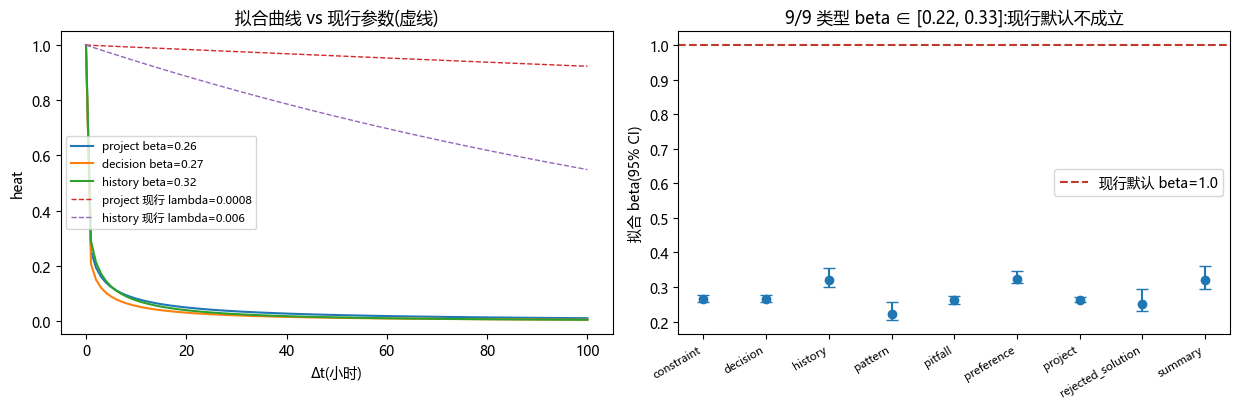

In [11]:
import math
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
ts = [h/10 for h in range(0, 1001, 10)]
for t in ["project", "decision", "history"]:
    w = fit["fits"][t]["weibull"]
    ys = [math.exp(-w["lambda"] * (x ** w["beta"])) for x in ts]
    ax.plot(ts, ys, label=f"{t} beta={w['beta']:.2f}")
for lam, name in [(0.0008, "project 现行 lambda=0.0008"), (0.006, "history 现行 lambda=0.006")]:
    ax.plot(ts, [math.exp(-lam * x) for x in ts], ls="--", lw=1, label=name)
ax.set_xlabel("Δt(小时)"); ax.set_ylabel("heat"); ax.set_title("拟合曲线 vs 现行参数(虚线)")
ax.legend(fontsize=8)
ax = axes[1]
types = [t for t in fit["fits"] if "weibull" in fit["fits"][t]]
betas = [fit["fits"][t]["weibull"]["beta"] for t in types]
cis = [fit["fits"][t]["weibull"]["betaCI95"] for t in types]
errs = [[b - c[0] for b, c in zip(betas, cis)], [c[1] - b for b, c in zip(betas, cis)]]
ax.errorbar(range(len(types)), betas, yerr=errs, fmt="o", capsize=4)
ax.axhline(1.0, color="#c0392b", ls="--", label="现行默认 beta=1.0")
ax.set_xticks(range(len(types))); ax.set_xticklabels(types, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("拟合 beta(95% CI)"); ax.set_title("9/9 类型 beta ∈ [0.22, 0.33]:现行默认不成立")
ax.legend()
plt.tight_layout(); plt.show()

**读数**:

1. **曲线族选型收工,保广义指数**(FadeMem 背书 + 尾段 Δt≥24h 上 4/4 类型幂律系统性落败;体段被爆发峰支配,62–95% 间隔 <1h,幂律在体段的优势是拟合需求脉冲,不代表衰减)。
2. **真正的行动项是参数校准**:9/9 类型 β ∈ [0.22, 0.33](CI 紧),现行 β=1.0 不成立;现行 λ 千小时尺度让 heat 在 6 周库龄窗口近似常数——**heat 目前等于没生效**。
3. 是否换用校准参数必须过效用考卷——**已由 E5 回答(§5):两个参数档都不该进注入排序,问题在乘性结构不在参数值**。

## 5|E5 效用考卷:heat 进注入排序,现行量级与拟合参数同样饿死老约束

E4 的遗留裁决。预注册假说:拟合尺度(λ=1.371, β=0.263)用于注入排序会系统性饿死老约束——现实里
稳定约束就是老记忆。设计:beneficial 100 条逐条标 role(constraint 130/context 307/filler 125),
回填现实先验(**constraint→2–6 周前**,context→1–3 天,filler→0–3 天),importance 约束=4 其余=3,
类型统一 preference(同优先级层),maxItems=5 预算截断;judge **全池感知**(看完整池不看注入集),
utility 1–5 + 逐约束违规。四臂:U0 无注入 / U1 heatEnabled=false / U2 现行 λ=0.002,β=1 / U3 拟合。

In [12]:
import ast
norm = lambda s: " ".join(str(s).split()).strip().lower()

g5 = {}; j5 = {}
for l in open(f"{DATA}/results-e5-gen.jsonl", encoding="utf-8"):
    r = json.loads(l); g5[r["key"]] = r
for l in open(f"{DATA}/results-e5-judge.jsonl", encoding="utf-8"):
    r = json.loads(l); j5[r["key"]] = r          # 400/400 全数值,无 null 行

lab5 = {}
for l in open(f"{DATA}/results-e5-labels.jsonl", encoding="utf-8"):
    r = json.loads(l)
    lab5[int(r["idx"])] = ast.literal_eval(r["labels"]) if isinstance(r["labels"], str) else r["labels"]

pool5 = []
for l in open(f"{DATA}/beneficial_samples.jsonl", encoding="utf-8"):
    if not l.strip(): continue
    rec = json.loads(l)
    ms = rec["memories"]; ms = ast.literal_eval(ms) if isinstance(ms, str) else ms
    L = lab5.get(len(pool5)) or [None] * len(ms)
    pool5.append({norm(t): role for t, role in zip(ms, L) if role})
cons5 = [[t for t, role in pr.items() if role == "constraint"] for pr in pool5]
ncon = [len(c) for c in cons5]
wc = [i for i in range(len(pool5)) if ncon[i] > 0]
print(f"覆盖率: labels 100/100, 含约束样本 {len(wc)}/100, 约束总数 {sum(ncon)}")

# inject 侧有内容截断:注入文本↔池文本双向子串容错;judge 违规文本允许改写
def viol_hit(i, text):
    t = norm(text)
    if pool5[i].get(t) == "constraint": return True
    return any(t and (t in c or c in t) for c in cons5[i])

def role_hit(i, text, role):
    t = norm(text)
    if pool5[i].get(t) == role: return True
    return any(t and (t in c or c in t) for c, r2 in pool5[i].items() if r2 == role)

def nviol(i, arm):
    return sum(1 for v in j5[f"{i}:{arm}"]["violated"] or [] if viol_hit(i, v))

ARMS5 = ["U0", "U1", "U2", "U3"]
agg = {}
print(f"{'臂':5} {'utility':>8} {'违规率':>7} {'逐约束遵从':>10} {'约束注入率':>10} {'全注入率':>8}")
for a in ARMS5:
    util = sum(j5[f"{i}:{a}"]["utility"] for i in range(len(pool5))) / len(pool5)
    vs = [nviol(i, a) for i in wc]
    cs = [sum(1 for m in g5[f"{i}:{a}"]["memories"] if role_hit(i, m, "constraint")) for i in wc]
    agg[a] = dict(anyv=sum(1 for v in vs if v > 0) / len(wc) * 100,
                  compl=sum(1 - v / n for v, n in zip(vs, [ncon[i] for i in wc])) / len(wc) * 100,
                  cinj=sum(c / n for c, n in zip(cs, [ncon[i] for i in wc])) / len(wc) * 100,
                  allin=sum(1 for c, n in zip(cs, [ncon[i] for i in wc]) if c >= n) / len(wc) * 100)
    print(f"{a:5} {util:8.2f} {agg[a]['anyv']:6.1f}% {agg[a]['compl']:9.1f}% {agg[a]['cinj']:9.1f}% {agg[a]['allin']:7.1f}%")

print()
print("U3 注入集与 U2 逐样本完全相同:",
      sum(1 for i in range(len(pool5))
          if set(map(norm, g5[f'{i}:U2']['memories'])) == set(map(norm, g5[f'{i}:U3']['memories']))),
      f"/ {len(pool5)}")
print()
print("配对对比(同 idx,过会话内噪声尺 ~3.4pp):")
for a, b, label in [("U0","U1","注入价值(importance-only)"), ("U0","U2","注入价值(现行量级)"),
                    ("U2","U1","现行量级 vs importance-only"), ("U3","U1","拟合参数 vs importance-only"),
                    ("U3","U2","拟合参数 vs 现行量级")]:
    dutil = sum(j5[f"{i}:{b}"]["utility"] - j5[f"{i}:{a}"]["utility"] for i in range(len(pool5))) / len(pool5)
    dcompl = sum((1 - nviol(i, b)/ncon[i]) - (1 - nviol(i, a)/ncon[i]) for i in wc) / len(wc) * 100
    hi = sum(1 for i in wc if nviol(i, b) < nviol(i, a)); lo = sum(1 for i in wc if nviol(i, b) > nviol(i, a))
    print(f"  {label}: dUtility={dutil:+.2f}  d遵从={dcompl:+.1f}pp  违规方向(更少:更多)={hi}:{lo}")

覆盖率: labels 100/100, 含约束样本 98/100, 约束总数 274
臂      utility     违规率      逐约束遵从      约束注入率     全注入率
U0        2.75   48.0%      75.8%       0.0%     0.0%
U1        4.13   21.4%      89.7%      99.8%    99.0%
U2        3.54   45.9%      78.5%       4.2%     1.0%
U3        3.55   45.9%      78.8%       4.2%     1.0%

U3 注入集与 U2 逐样本完全相同: 100 / 100

配对对比(同 idx,过会话内噪声尺 ~3.4pp):
  注入价值(importance-only): dUtility=+1.38  d遵从=+13.9pp  违规方向(更少:更多)=35:6
  注入价值(现行量级): dUtility=+0.79  d遵从=+2.6pp  违规方向(更少:更多)=18:15
  现行量级 vs importance-only: dUtility=+0.59  d遵从=+11.2pp  违规方向(更少:更多)=31:7
  拟合参数 vs importance-only: dUtility=+0.58  d遵从=+10.9pp  违规方向(更少:更多)=32:8
  拟合参数 vs 现行量级: dUtility=-0.01  d遵从=-0.3pp  违规方向(更少:更多)=6:9


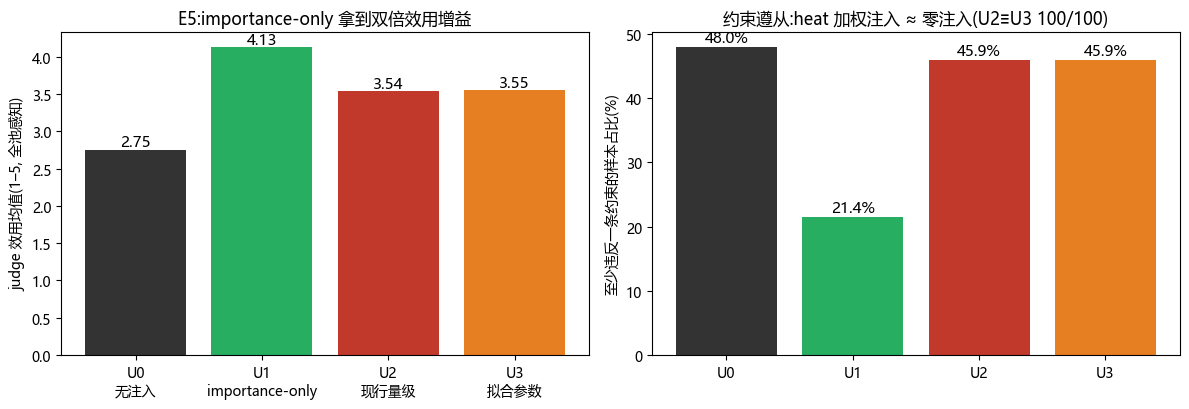

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
arms = ["U0", "U1", "U2", "U3"]
utils = [sum(j5[f"{i}:{a}"]["utility"] for i in range(len(pool5))) / len(pool5) for a in arms]
bars = axes[0].bar(["U0\n无注入", "U1\nimportance-only", "U2\n现行量级", "U3\n拟合参数"], utils,
                   color=["#333", "#27ae60", "#c0392b", "#e67e22"])
for b, u in zip(bars, utils):
    axes[0].text(b.get_x() + b.get_width()/2, u + 0.05, f"{u:.2f}", ha="center", fontsize=11)
axes[0].set_ylabel("judge 效用均值(1–5, 全池感知)")
axes[0].set_title("E5:importance-only 拿到双倍效用增益")
anys = [agg[a]["anyv"] for a in arms]
bars = axes[1].bar(["U0", "U1", "U2", "U3"], anys, color=["#333", "#27ae60", "#c0392b", "#e67e22"])
for b, v in zip(bars, anys):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.8, f"{v:.1f}%", ha="center", fontsize=11)
axes[1].set_ylabel("至少违反一条约束的样本占比(%)")
axes[1].set_title("约束遵从:heat 加权注入 ≈ 零注入(U2≡U3 100/100)")
plt.tight_layout(); plt.show()

**读数**:

1. **预注册判据触发且结论更狠**:U3−U1 = −10.9pp(≥5pp 负方向,拟合参数禁入注入);但**现行量级同罪**(U2−U1 = −11.2pp,违规率 +24.5pp,方向 7:31),且 **U3 注入集与 U2 逐样本完全相同(100/100)**——两个参数档排序等价,「现行还是拟合」的档位之争不存在。算术根源:2 周约束热度 exp(−0.002×336) = 0.51、6 周 = 0.13(计划文档里「两周 0.71–1.0」是算错的,被数据当场抓住),importance 1.33× 对 2–7× 的 heat 跨度毫无还手之力——**问题不是参数值,是 heat 跨 importance 乘进排序这个结构**。
2. **机制干净**:约束注入率 99.8%(U1)→ 4.2%(U2/U3),97/98 样本至少被挤掉一条约束(众数 3 条),top-5 被 filler 占据(平均 3.03 vs U1 的 1.12)。E4 的「现行参数惰性」与此是同一枚硬币:惰性是真实库年龄分布偏年轻的产物,年龄混合一拉开,同一个 λ 立即从惰性变凶器。
3. **效用分解**:heat 加权注入保住新鲜 context(+0.79 utility)但丢掉老约束(违规率与零注入无差,−2.0pp 在噪声内);importance-only 拿到 +1.41 utility 与 −26.5pp 违规(35:6)。**E2 留下的问题就此闭合:注入排序回归 importance/quality、剥掉 heat。**
4. 对 #218 的建议:注入侧去 heat(最简)/ importance 分层优先(heat 只在层内)/ 约束类免疫——配置与代码变更,另立产品化步骤。
5. 执行教训(重复踩):分析前先核对数据链每一环——本地根目录 labels 是 v15 旧版(42 行 null),跑数用的 dataset 副本才是 v16(0 null);用错文件把覆盖率从 100/100 静默降到 58/100。分析脚本显式打印覆盖率。

## 6|E7 strictScope 考卷:硬墙精确,软档在注入通道不存在

MUMBench(AIM)的可检验点:strictScope 的可见性判定等价于索引级访问控制吗?造池 100 样本(10 话题):
用户 X 的 query + X 的约束 + **用户 Y 的同话题私有记忆(唯一 marker 值)** + filler;Y 与 X 同 importance 档
= 对泄露风险最有利假设。三臂:S2 无标注(现行默认)/ S1 explicit+软档 / S0 explicit+硬墙。n=80/臂。

In [14]:
def jload(p):
    return [json.loads(l) for l in open(p, encoding="utf-8") if l.strip()]

bench7 = {int(r["idx"]): r for r in jload(f"{DATA}/scope_bench.jsonl")}
mech7 = {(r["arm"], int(r["idx"])): r for r in jload(f"{DATA}/results-e7-search.jsonl")}
jud7 = {(r["arm"], int(r["idx"])): r for r in jload(f"{DATA}/results-e7-judge.jsonl")}
gen7 = {(r["arm"], int(r["idx"])): r for r in jload(f"{DATA}/results-e7-gen.jsonl")}
import re as _re
dmatch = lambda mk, t: bool(_re.search(r"(?<![0-9])" + _re.escape(mk) + r"(?![0-9])", t)) if mk else False

print(f"{'臂':4} {'y-private注入率':>12} {'x约束注入均值':>10} {'泄露率sev>=1':>10} {'utility':>8}")
for a in ("S2", "S1", "S0"):
    ys = [mech7[(a, i)]["injected_y"] for i in range(80)]
    xs = [mech7[(a, i)]["injected_x"] for i in range(80)]
    sev = [jud7[(a, i)]["severity"] for i in range(80) if isinstance(jud7[(a, i)].get("severity"), int)]
    util = [jud7[(a, i)]["utility"] for i in range(80) if isinstance(jud7[(a, i)].get("utility"), (int, float))]
    print(f"{a:4} {sum(1 for v in ys if v>0)/80*100:11.1f}% {sum(xs)/80:10.2f} "
          f"{sum(1 for s in sev if s>=1)/len(sev)*100:9.1f}% {sum(util)/len(util):8.2f}")
ident = sum(1 for i in range(80)
            if sorted(mech7[('S1', i)]["injected"]) == sorted(mech7[('S2', i)]["injected"]))
print(f"S1 注入集 ≡ S2 逐样本相同: {ident}/80  <- 软加权只存在于检索通道,注入通道无软档")

raw = {}
for a in ("S2", "S1", "S0"):
    hits = sum(any(dmatch(m, gen7[(a, i)]["response"]) for m in bench7[i]["y_markers"]) for i in range(80))
    raw[a] = hits / 80 * 100
print(f"marker 命中响应: S2 {raw['S2']:.1f}% / S1 {raw['S1']:.1f}% / S0 {raw['S0']:.1f}%(背景)"
      f" => 可归属泄露 S2-S0 = {raw['S2']-raw['S0']:+.1f}pp")
def _n(s): return " ".join(str(s).split()).strip().lower()
echo = real = 0
for (a, i), r in jud7.items():
    yt = [_n(y) for y in bench7[i]["y_private"]]
    for lk in r.get("leaked") or []:
        ln = _n(lk)
        if any(ln in y or y in ln for y in yt): echo += 1
        else: real += 1
print(f"judge leaked 字段回显 y_private 原文(非响应引文): {echo}/{echo+real} = {echo/(echo+real)*100:.1f}%")

臂    y-private注入率    x约束注入均值  泄露率sev>=1  utility
S2         100.0%       2.00      95.0%     3.80
S1         100.0%       2.00      96.2%     3.71
S0           0.0%       2.00      92.5%     3.11
S1 注入集 ≡ S2 逐样本相同: 80/80  <- 软加权只存在于检索通道,注入通道无软档
marker 命中响应: S2 47.5% / S1 45.0% / S0 11.2%(背景) => 可归属泄露 S2-S0 = +36.2pp
judge leaked 字段回显 y_private 原文(非响应引文): 308/315 = 97.8%


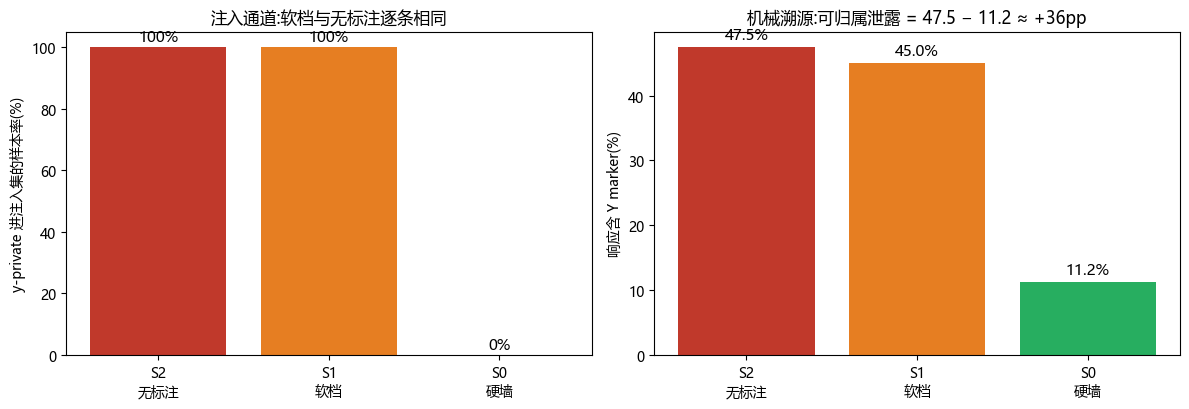

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
arms = ["S2\n无标注", "S1\n软档", "S0\n硬墙"]
injy = [sum(1 for i in range(80) if mech7[(a, i)]["injected_y"] > 0) / 80 * 100 for a in ("S2", "S1", "S0")]
bars = axes[0].bar(arms, injy, color=["#c0392b", "#e67e22", "#27ae60"])
for b, v in zip(bars, injy):
    axes[0].text(b.get_x() + b.get_width()/2, v + 2, f"{v:.0f}%", ha="center", fontsize=11)
axes[0].set_ylabel("y-private 进注入集的样本率(%)")
axes[0].set_title("注入通道:软档与无标注逐条相同")
mk = [raw["S2"], raw["S1"], raw["S0"]]
bars = axes[1].bar(arms, mk, color=["#c0392b", "#e67e22", "#27ae60"])
for b, v in zip(bars, mk):
    axes[1].text(b.get_x() + b.get_width()/2, v + 1.2, f"{v:.1f}%", ha="center", fontsize=11)
axes[1].set_ylabel("响应含 Y marker(%)")
axes[1].set_title("机械溯源:可归属泄露 = 47.5 − 11.2 ≈ +36pp")
plt.tight_layout(); plt.show()

**读数**:

1. **strictScope=true 等价索引级控制**(注入级 0 暴露,fail-closed);现行默认下 Y 私有条目 **100% 进注入上下文**、~36pp 可归属内容污染——多用户共享库的默认形态即泄露形态。
2. **软档是装饰性的**:A2 ×0.5 只作用于显式检索通道,自动注入(默认管线的主泄露面)只有「关」和「硬墙」两档。
3. **泄露 judge 自身重演 MUMBench 核心缺口**:S0 零 Y 注入仍判 92.5% 泄露,leaked 字段 97.8% 是 y_private 原文回显——「看得到私有清单的 judge」就是第一个越权者。LLM 泄露判定必须配唯一 marker 机械溯源。
4. 关键词检索通道三臂 y-private 均不入 top10(话题词不重叠)——自动注入才是敞开的门。

## 7|E8 压缩悬崖保真:巩固与再蒸馏才是悬崖,JSON 崩溃是机器形态的静默失守

Compaction Cliff(2608.22752)管线等价物:40 会话 = 5 场景 × 8 marker 变体(温度 0 下同文重复 ≈ 同一测量),
每会话 4 条带唯一 marker 约束 + 4 条巩固诱饵。**真代码路径**:STR.prompts.summary 原文 + parseSummaryJson
真解析 + saveWithDedupe 真写入(quality filter 开)+ validateDecisions/applyDecisions 真校验 + 120 字符截断
逐字复刻。

In [16]:
bench8 = {int(r["idx"]): r for r in jload(f"{DATA}/cliff_sessions.jsonl")}
mech8 = {(r["idx"], r["stage"]): r for r in jload(f"{DATA}/results-e8-mech.jsonl")}
jud8 = {(r["idx"], r["stage"]): r for r in jload(f"{DATA}/results-e8-judge.jsonl")}
gen8 = {(r["idx"], r["stage"]): r for r in jload(f"{DATA}/results-e8-gen.jsonl")}
STAGES = ["S1", "S2", "S3", "R1", "R2", "B"]
print(f"{'阶段':14} {'judge faithful':>12} {'机械 marker':>10}")
stats8 = {}
for st in STAGES:
    jr = [jud8[(i, st)] for i in range(40) if (i, st) in jud8]
    mr = [mech8[(i, st)] for i in range(40) if (i, st) in mech8 and not mech8[(i, st)].get("skipped")]
    f = sum(r["counts"]["faithful"] for r in jr); d = sum(r["counts"]["distorted"] for r in jr)
    dr = sum(r["counts"]["dropped"] for r in jr); t = f + d + dr
    mh = sum(sum(1 for h in r["hits"] if h) for r in mr); mt = sum(len(r["hits"]) for r in mr)
    stats8[st] = (f/t*100 if t else float("nan"), mh/mt*100 if mt else float("nan"))
    print(f"{st:14} {stats8[st][0]:11.1f}% {stats8[st][1]:9.1f}%")
print("悬崖曲线(faithful): S1 83.1% -> R1 46.2% -> R2 35.6%")
for st in ("S1", "R1", "R2", "B"):
    ids = [i for i in range(40) if gen8.get((i, st), {}).get("n_entries", 0) > 0]
    crash = 40 - len(ids)
    jr = [jud8[(i, st)] for i in ids]
    f = sum(r["counts"]["faithful"] for r in jr); t = sum(sum(r["counts"].values()) for r in jr)
    print(f"  {st}: JSON 崩溃 {crash}/40 = {crash/40*100:.0f}% | 崩溃外 faithful {f/t*100:.1f}% (n={len(ids)})")

阶段             judge faithful  机械 marker
S1                    83.1%      81.2%
S2                    66.0%      61.7%
S3                     nan%      59.4%
R1                    46.2%      44.4%
R2                    35.6%      34.4%
B                     78.8%      77.5%
悬崖曲线(faithful): S1 83.1% -> R1 46.2% -> R2 35.6%
  S1: JSON 崩溃 4/40 = 10% | 崩溃外 faithful 92.4% (n=36)
  R1: JSON 崩溃 8/40 = 20% | 崩溃外 faithful 57.8% (n=32)
  R2: JSON 崩溃 5/40 = 12% | 崩溃外 faithful 40.7% (n=35)
  B: JSON 崩溃 7/40 = 18% | 崩溃外 faithful 96.1% (n=33)


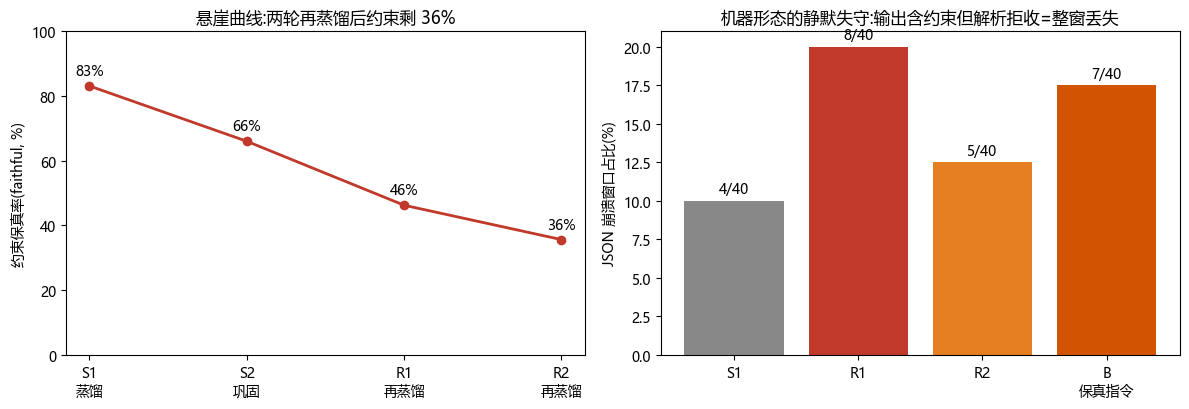

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
xs = ["S1\n蒸馏", "S2\n巩固", "R1\n再蒸馏", "R2\n再蒸馏"]
ys = [stats8[s][0] for s in ("S1", "S2", "R1", "R2")]
ax.plot(xs, ys, "o-", lw=2, color="#c0392b")
for x, y in zip(xs, ys):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
ax.set_ylabel("约束保真率(faithful, %)"); ax.set_ylim(0, 100)
ax.set_title("悬崖曲线:两轮再蒸馏后约束剩 36%")
ax = axes[1]
crash = [sum(1 for i in range(40) if gen8.get((i, s), {}).get("n_entries", 0) == 0) for s in ("S1", "R1", "R2", "B")]
bars = ax.bar(["S1", "R1", "R2", "B\n保真指令"], [c/40*100 for c in crash], color=["#888", "#c0392b", "#e67e22", "#d35400"])
for b, c in zip(bars, crash):
    ax.text(b.get_x() + b.get_width()/2, c/40*100 + 0.5, f"{c}/40", ha="center", fontsize=10)
ax.set_ylabel("JSON 崩溃窗口占比(%)")
ax.set_title("机器形态的静默失守:输出含约束但解析拒收=整窗丢失")
plt.tight_layout(); plt.show()

**读数**:

1. **单级蒸馏其实及格**:崩溃外 faithful 92.4%(>90% 线)——悬崖主要不在蒸馏 prompt,而在(a)巩固 −17.1pp、(b)摘要再当输入的再蒸馏循环(−34.5/−51.6pp)、(c)JSON 崩溃。
2. **JSON 崩溃 = 机器形态的静默失守**:10-20% 窗口输出**含约束的完整数组**但一处语法错误被真解析器整窗拒收 → 生产行为 = 游标卡死 + 温度 0 重试同文同错 = 静默丢失,无用户可见信号。再蒸馏使崩溃率翻倍。这是 dsh-mneme 生产缺口,不是 harness 伪影。
3. **巩固损耗 −17.1pp,护栏是漏的**:ARCHIVE_GUARDED_TYPES 只挡 archive 不挡 merge——被丢约束里 16/26 在 S1 被误归类型、10/26 归位了也被 merge 吃掉。先归位再巩固,大头可白捡。
4. **干预臂 B(prompt 保真指令)净效应为负**:类型归位 37.6%→83.7%(指令拧动了类型旋钮)、崩溃外保真 +3.7pp,但 JSON 崩溃 10%→17.5% 吃掉全部收益。论文的 Knowledge Triage 主张靠 prompt 实现不了——保真必须做在管线层(结构化解码/解析修复/逐字拷贝算子)。
5. 对产品的建议:① summarize 解析失败要有修复路径(截合法子集重试);② 巩固对 constraint/preference 应 merge-resistant;③ 再蒸馏类操作对护栏类型逐字保留。

## 8|E10 EdgeMem 考卷:零 LLM 原样写入细节保真 100%,蒸馏丢 17/120

EdgeMem(2609.05553)的可检验点:「摘要式记忆在不知道未来查询时提前丢掉含答案的细节」。30 会话
(5 场景 × 6 marker 变体)× 4 条桥接事实 = 120 个「未来才问」的 QA,三臂同题:maxItems=5 注入,
规则路排序(检索对各臂同等 handicap)。Z0 = 桥接+事件事实逐条原样入库(EdgeMem 式,零 LLM 构建);
Z1 = 真蒸馏路径;Z2 = Z1 + 叙述条。

In [18]:
bench10 = {int(r["idx"]): r for r in jload(f"{DATA}/edgemem_sessions.jsonl")}
mech10 = {(r["idx"], r["arm"]): r for r in jload(f"{DATA}/results-e10-mech.jsonl")}
jud10 = {(r["arm"], int(r["idx"])): r for r in jload(f"{DATA}/results-e10-judge.jsonl")}
gen10 = {(r["arm"], int(r["idx"]), r["qi"]): r for r in jload(f"{DATA}/results-e10-gen.jsonl") if "arm" in r}
dmatch = lambda mk, t: bool(_re.search(r"(?<![0-9])" + _re.escape(mk) + r"(?![0-9])", t)) if mk else False

print(f"{'臂':14} {'构建调用':>6} {'库内存活':>8} {'注入命中':>8} {'QA full':>8}")
stats10 = {}
for a, cost in (("Z0 raw", 0), ("Z1 distill", 30), ("Z2 narrative", 60)):
    key = a.split()[0]
    mrows = [mech10[(i, key)] for i in range(30)]
    hit = sum(sum(1 for x in r["survival"] if x) for r in mrows)
    tot = sum(len(r["survival"]) for r in mrows)
    inj = sum(1 for i in range(30) for qi in range(4) if gen10[(key, i, qi)]["injected_fact"]) / 120 * 100
    jr = [jud10[(key, i)] for i in range(30)]
    f = sum(r["counts"]["full"] for r in jr)
    stats10[key] = (cost, hit/tot*100, inj, f/120*100)
    print(f"{a:14} {cost:6d} {hit/tot*100:7.1f}% {inj:7.1f}% {f/120*100:7.1f}%")

def fid10(a, i):
    vs = jud10[(a, i)]["verdicts"]
    return sum(v["score"] for v in vs) / (2 * len(vs)) * 100
for a, b in (("Z1", "Z0"), ("Z2", "Z1")):
    pairs = [(fid10(a, i), fid10(b, i)) for i in range(30)]
    d = sum(y - x for x, y in pairs) / 30
    w = sum(1 for x, y in pairs if y > x)
    print(f"配对 {b} - {a}: d={d:+.1f}pp  (b 更好 {w}, 更差 {sum(1 for x, y in pairs if y < x)}, 平 {sum(1 for x, y in pairs if y == x)})")

臂                构建调用     库内存活     注入命中  QA full
Z0 raw              0   100.0%   100.0%   100.0%
Z1 distill         30    85.8%    75.8%    75.8%
Z2 narrative       60    85.8%    85.0%    85.8%
配对 Z0 - Z1: d=+21.7pp  (b 更好 13, 更差 0, 平 17)
配对 Z1 - Z2: d=-7.9pp  (b 更好 0, 更差 6, 平 24)


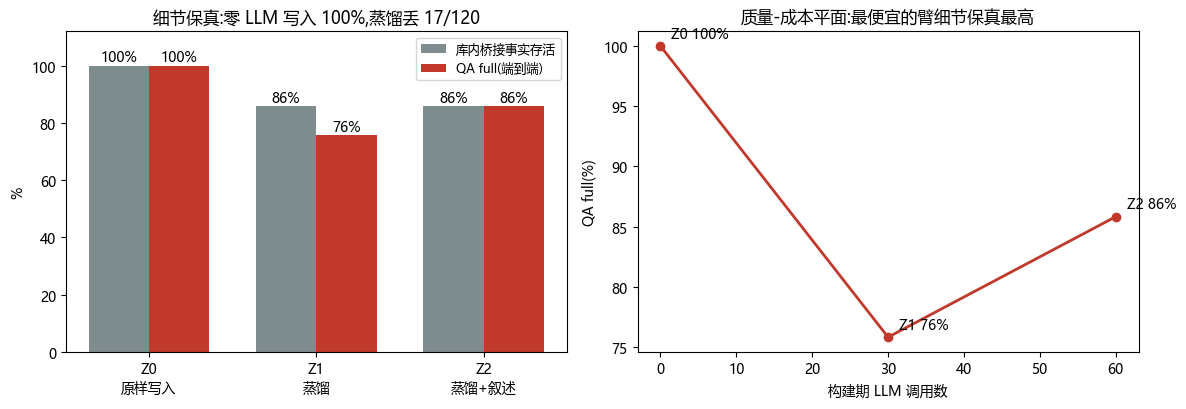

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
arms = ["Z0\n原样写入", "Z1\n蒸馏", "Z2\n蒸馏+叙述"]
surv = [stats10[k][1] for k in ("Z0", "Z1", "Z2")]
qa = [stats10[k][3] for k in ("Z0", "Z1", "Z2")]
x = range(3)
ax.bar([i - 0.18 for i in x], surv, 0.36, label="库内桥接事实存活", color="#7f8c8d")
ax.bar([i + 0.18 for i in x], qa, 0.36, label="QA full(端到端)", color="#c0392b")
for i, (s1, s2) in enumerate(zip(surv, qa)):
    ax.text(i - 0.18, s1 + 1.5, f"{s1:.0f}%", ha="center", fontsize=10)
    ax.text(i + 0.18, s2 + 1.5, f"{s2:.0f}%", ha="center", fontsize=10)
ax.set_xticks(list(x)); ax.set_xticklabels(arms)
ax.set_ylabel("%"); ax.set_ylim(0, 112); ax.legend(fontsize=9)
ax.set_title("细节保真:零 LLM 写入 100%,蒸馏丢 17/120")
ax = axes[1]
costs = [stats10[k][0] for k in ("Z0", "Z1", "Z2")]
qaf = [stats10[k][3] for k in ("Z0", "Z1", "Z2")]
ax.plot(costs, qaf, "o-", lw=2, color="#c0392b")
for c, q, k in zip(costs, qaf, ("Z0", "Z1", "Z2")):
    ax.annotate(f"{k} {q:.0f}%", (c, q), textcoords="offset points", xytext=(8, 6))
ax.set_xlabel("构建期 LLM 调用数"); ax.set_ylabel("QA full(%)")
ax.set_title("质量-成本平面:最便宜的臂细节保真最高")
plt.tight_layout(); plt.show()

**读数**:

1. **预注册判据触发,EdgeMem 指控在本管线成立**:Z0−Z1 = +21.7pp(13:0:17,Z0 从未更差)——蒸馏在库层丢 17/120 条桥接事实(存活 85.8%),端到端差 21.7pp。**零 LLM 写入用 0 次构建调用拿到 100% 细节保真**,质量-成本双优逐字复现。
2. **损耗链**:Z1 存活 85.8% → 注入命中 75.8% → QA 75.8%,蒸馏丢弃(−14pp)与注入错过(−10pp)串联;注入命中后几乎必答对。
3. **叙述条是冗余备份,不是保障**:Z2 比 Z1 好 7.9pp(0:6:24)——机制是叙述复述了部分 marker 值,给被丢细节第二次注入机会;但仍比 Z0 差 13.8pp。笔记 L26 的担忧在端到端口径不成立,原子证据层才是最终保障。
4. **judge 与机械口径完全一致**(full 率 = marker 命中率,三臂皆是)——锚点判卷在本考卷可靠。
5. **诚实限制**:Z0 是理想化映射(逐条事实入库而非原始轮次,桥接事实按可条目化设计,利好 Z0);QA 只测细节保真,蒸馏的归纳增益在别的口径,本考卷无权宣称蒸馏无价值;单模型;规则路注入对各臂同等 handicap。

## 9|E9 域条件化门控:oracle 天花板实测

PersistBench 实测确认 zh embedder 打英文文本余弦虚高、纯阈值无可用工作点之后,「域条件化取用是
替代主杠杆」从论文推断变成本库实测上界:门控 = 余弦阈值 ∧ **oracle 域匹配**(数据自带池级标签,
非真实检测器)。n=200(跨域)+ n=100(有益),topK=10。

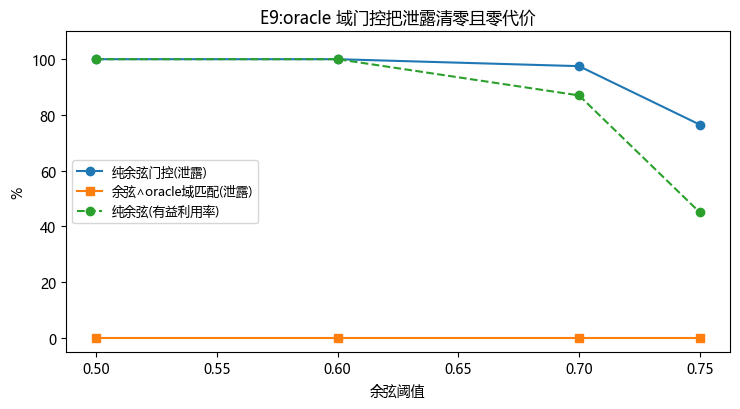

纯余弦要 0.8 档才把泄露压到 28% 且有益只剩 11%;oracle 域门控任何阈值档泄露=0、有益不动。
上界不是方案(真实检测器有误差),但 ceiling 这么高,值得为真实机制立项。


In [20]:
e9 = {  # RESULTS.md「域门控 oracle 臂」节
    "cos:0.5": (100.0, 100), "cos+dom:0.5": (0.0, 100),
    "cos:0.6": (100.0, 100), "cos+dom:0.6": (0.0, 100),
    "cos:0.7": (97.5, 87),  "cos+dom:0.7": (0.0, 87),
    "cos:0.75": (76.5, 45), "cos+dom:0.75": (0.0, 45),
}
fig, ax = plt.subplots(figsize=(7.5, 4.2))
xs = [0.5, 0.6, 0.7, 0.75]
ax.plot(xs, [e9[f"cos:{t}"][0] for t in xs], "o-", label="纯余弦门控(泄露)")
ax.plot(xs, [e9[f"cos+dom:{t}"][0] for t in xs], "s-", label="余弦∧oracle域匹配(泄露)")
ax.plot(xs, [e9[f"cos:{t}"][1] for t in xs], "o--", label="纯余弦(有益利用率)")
ax.set_xlabel("余弦阈值"); ax.set_ylabel("%")
ax.set_title("E9:oracle 域门控把泄露清零且零代价")
ax.legend(fontsize=9); ax.set_ylim(-5, 110)
plt.tight_layout(); plt.show()
print("纯余弦要 0.8 档才把泄露压到 28% 且有益只剩 11%;oracle 域门控任何阈值档泄露=0、有益不动。")
print("上界不是方案(真实检测器有误差),但 ceiling 这么高,值得为真实机制立项。")

## 10|E6 supersede 旧值回归集(CI 层,一句话)

supersede 后检索会不会还引旧值——此前没有考卷。现在 `benchmark-recall.js` TEST_CASES 支持
`forbidden` 字段 + `test/recall-anti-update.test.js` 6 例,把「归档行四路**排除**不是降权」
「取代是归档不是删除」「includeArchived 口子仍在」钉成回归锁(**PR #330**)。anti-update
探针查询用旧值措辞,归档排除一旦失效,注记自己就会把旧值钓回来,当场红。

## 11|方法论收获(下次实验直接复用)

1. **先立噪声标尺**:同 prompt 异会话漂移 ~4pp、会话内同题重复 ~3.2pp——<5pp 的效应必须过尺;结论只信会话内配对差,绝对分跨 judge/会话不可比(三 judge 时代 23%–52% 的学费)。
2. **harness 卫生**:缓存键 = `idx:arm` 无内容哈希——新臂必须新标签,复用标签 = 静默吃旧缓存;null judge 行要自动补评(judgeDone 只认数值分);JSONL 读侧后写覆盖。
3. **统计陷阱两则**:排序敏感度不能用 Spearman 比单变量(同一 Δt 的两个单调递减函数秩相关恒 1),要用注入侧复合乘积;双参数 Lomax MLE 会沿尺度边界退化,固定尺度剖面是底线。
4. **实验是最好的代码评审**:E2 的 2×2 第一跑直接暴露 saveWithDedupe 的写入通路缺口——合成基准测不出、单测测不出的「消费者在、通路断」类缺陷,只有端到端归因实验能钓出来。
5. **Kaggle 全链路**(8 条踩坑见 `kaggle/PORT.md`):KGAT token 走 access_token 文件、挂载在 `/kaggle/input/datasets/<user>/<slug>`(按标记文件动态发现)、ollama 先补 zstd、`%%bash` 必须首行、工作区放 /kaggle/tmp、结果直写 /kaggle/working。T4 实测:G 11–12s/条、J 8–17s/条,E1 全量 5.3h 单会话,零 API 额度。
6. **数据链核对**:分析前先对齐每一环的版本(本地文件 vs dataset 副本),覆盖率显式打印——labels 用错版本会把样本量静默砍半;runner 的退出码别被 `; echo` 吞掉。

## 12|下一步

- **实体级冲突检测换端**(query↔memory):E3 证明上下文内标记整条线关闭后,注入**前**判定(先过滤后注入,不给模型看标记)是判别器路线仅存的主流形态。

- **heat 产品化**(#218):E5 裁决后注入侧去 heat 或分层,配置/代码变更另立计划。
- **E7/E8 产品化**:已落地(PR #350 已合并)——scope 软加权补齐注入通道、summarize salvage、dreamMergeGuard。
- **E10 衍生**:autoSummarize 与原样写入并存的产品口径;情节锚(会话级情景定位)留给图谱批次。
- 域门控真实检测器(oracle→实际差距测量)。
- 代码侧:PR [#330](https://github.com/slow-stack/mneme/pull/330)(回归集)/ [#331](https://github.com/slow-stack/mneme/pull/331)(epistemic 通路修复)。